# Document Type Classification for BMC Pipeline

This notebook trains a document type classifier that decides whether an input image is:

- **BMC**
- **Non-BMC Handwritten**
- **Non-BMC Typed**

This classifier is used before the YOLO stage in the full BMC pipeline. If the image is classified as **BMC**, it is sent to YOLO for the 9-block detection. Otherwise, the image is rejected or processed as a normal document.

Datasets used:

- Personal BMC images
- IAM Handwriting Word Database
- RVL-CDIP Small

## 1. Install and Import Libraries

This section installs and imports all libraries needed for training, evaluation, visualization, XAI, and model deployment.

In [1]:
!pip install -q timm scikit-learn matplotlib pillow tqdm

import os
import glob
import random
import shutil
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models
import timm

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 2. Configuration

Change only the dataset paths if needed. On Kaggle, add the 3 datasets from **Add Input**, then update the paths below according to the exact folder names.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
NUM_CLASSES = 3

CLASS_NAMES = [
    "bmc",
    "non_bmc_handwritten",
    "non_bmc_typed"
]

# =============================
# IMPORTANT: CHANGE BMC PATH
# =============================
# Put your own BMC images dataset path here.
# Example: /kaggle/input/my-bmc-images
BMC_SOURCE_DIR = "/kaggle/input/datasets/fatmaadorgham/bmc-data"

# Kaggle datasets:
IAM_ROOT   = "/kaggle/input/datasets/nibinv23/iam-handwriting-word-database/iam_words"
WORDS_TXT  = "/kaggle/input/datasets/nibinv23/iam-handwriting-word-database/iam_words/words.txt"
WORDS_DIR  = "/kaggle/input/datasets/nibinv23/iam-handwriting-word-database/iam_words/words"

IAM_SOURCE_DIR = WORDS_DIR

RVL_SOURCE_DIR = "/kaggle/input/datasets/uditamin/rvl-cdip-small"
OUTPUT_DATASET_DIR = "/kaggle/working/doc_type_dataset"
OUTPUT_MODEL_DIR = "/kaggle/working/doc_type_models"
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)

print("BMC path:", BMC_SOURCE_DIR)
print("IAM path:", IAM_SOURCE_DIR)
print("RVL path:", RVL_SOURCE_DIR)

BMC path: /kaggle/input/datasets/fatmaadorgham/bmc-data
IAM path: /kaggle/input/datasets/nibinv23/iam-handwriting-word-database/iam_words/words
RVL path: /kaggle/input/datasets/uditamin/rvl-cdip-small


## 3. Utility Functions

These functions collect images from folders, handle `.jpg`, `.png`, `.tif`, and `.tiff` files, convert all images to RGB, and split the dataset into train/validation/test.

In [3]:
def is_image_file(path):
    valid_ext = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
    return os.path.splitext(path.lower())[1] in valid_ext


def collect_images(root_dir):
    images = []
    if not os.path.exists(root_dir):
        print(f"WARNING: Path does not exist: {root_dir}")
        return images

    for path in glob.glob(root_dir + "/**/*", recursive=True):
        if os.path.isfile(path) and is_image_file(path):
            images.append(path)
    return images


def safe_copy_image(src_path, dst_path):
    try:
        img = Image.open(src_path).convert("RGB")
        img.save(dst_path, "JPEG", quality=95)
        return True
    except Exception as e:
        return False


def split_list(items, train_ratio=0.70, val_ratio=0.15):
    items = items.copy()
    random.shuffle(items)
    n = len(items)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return items[:train_end], items[train_end:val_end], items[val_end:]

## 4. Build the Classification Dataset

The final dataset has this structure:

```text
doc_type_dataset/
├── train/
│   ├── bmc/
│   ├── non_bmc_handwritten/
│   └── non_bmc_typed/
├── val/
│   ├── bmc/
│   ├── non_bmc_handwritten/
│   └── non_bmc_typed/
└── test/
    ├── bmc/
    ├── non_bmc_handwritten/
    └── non_bmc_typed/
```

In [4]:
if os.path.exists(OUTPUT_DATASET_DIR):
    shutil.rmtree(OUTPUT_DATASET_DIR)

for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(OUTPUT_DATASET_DIR, split, cls), exist_ok=True)

print("Dataset folders created successfully.")

Dataset folders created successfully.


In [5]:
bmc_images = collect_images(BMC_SOURCE_DIR)
iam_images = collect_images(IAM_SOURCE_DIR)
rvl_images = collect_images(RVL_SOURCE_DIR)

print("Found BMC images:", len(bmc_images))
print("Found IAM handwritten images:", len(iam_images))
print("Found RVL typed document images:", len(rvl_images))

if len(bmc_images) == 0:
    raise ValueError("No BMC images found. Please update BMC_SOURCE_DIR with your BMC image dataset path.")
if len(iam_images) == 0:
    raise ValueError("No IAM images found. Please check IAM_SOURCE_DIR.")
if len(rvl_images) == 0:
    raise ValueError("No RVL images found. Please check RVL_SOURCE_DIR.")

Found BMC images: 1361
Found IAM handwritten images: 115320
Found RVL typed document images: 47996


In [6]:
# ============================================================
# FIX: Convert IAM word images into document-like handwritten pages
# Put this AFTER collecting images and BEFORE balancing
# ============================================================

from PIL import Image, ImageOps, ImageEnhance
import math

IAM_DOC_DIR = "/kaggle/working/iam_generated_handwritten_docs"

if os.path.exists(IAM_DOC_DIR):
    shutil.rmtree(IAM_DOC_DIR)

os.makedirs(IAM_DOC_DIR, exist_ok=True)

def create_handwritten_page(word_paths, save_path, page_w=900, page_h=1200):
    page = Image.new("RGB", (page_w, page_h), "white")

    x_margin = random.randint(50, 80)
    y = random.randint(50, 90)
    line_height = random.randint(45, 65)

    x = x_margin

    for word_path in word_paths:
        try:
            word = Image.open(word_path).convert("L")
            word = ImageOps.invert(word)
            word = ImageOps.autocontrast(word)
            word = ImageOps.invert(word)

            word = word.convert("RGB")

            # Resize word to realistic handwritten size
            w, h = word.size
            if h == 0 or w == 0:
                continue

            target_h = random.randint(22, 35)
            new_w = int(w * (target_h / h))
            word = word.resize((max(5, new_w), target_h))

            # Small rotation
            angle = random.uniform(-3, 3)
            word = word.rotate(angle, expand=True, fillcolor="white")

            # New line if needed
            if x + word.size[0] > page_w - x_margin:
                x = x_margin
                y += line_height

            if y + word.size[1] > page_h - 60:
                break

            page.paste(word, (x, y))
            x += word.size[0] + random.randint(12, 28)

        except:
            continue

    # Add slight document realism
    page = ImageEnhance.Contrast(page).enhance(random.uniform(0.9, 1.2))
    page.save(save_path, "JPEG", quality=95)


# Number of generated handwritten documents
N_IAM_DOCS = 3000
# Shuffle IAM words and group them into pages
random.shuffle(iam_images)

words_per_page = 60
needed_words = N_IAM_DOCS * words_per_page

if len(iam_images) < needed_words:
    print("Warning: IAM words are fewer than expected, sampling with replacement.")
    selected_words = random.choices(iam_images, k=needed_words)
else:
    selected_words = iam_images[:needed_words]

for i in tqdm(range(N_IAM_DOCS), desc="Generating IAM handwritten documents"):
    page_words = selected_words[i * words_per_page : (i + 1) * words_per_page]
    save_path = os.path.join(IAM_DOC_DIR, f"iam_doc_{i}.jpg")
    create_handwritten_page(page_words, save_path)

# IMPORTANT: replace IAM word images with generated document-like images
iam_images = collect_images(IAM_DOC_DIR)

print("Generated handwritten document images:", len(iam_images))
print("Example:", iam_images[:3])

Generating IAM handwritten documents: 100%|██████████| 3000/3000 [19:10<00:00,  2.61it/s]

Generated handwritten document images: 3000
Example: ['/kaggle/working/iam_generated_handwritten_docs/iam_doc_1131.jpg', '/kaggle/working/iam_generated_handwritten_docs/iam_doc_1163.jpg', '/kaggle/working/iam_generated_handwritten_docs/iam_doc_1200.jpg']


In [7]:
# ============================================================
# HARD NEGATIVES: Generate fake grid/table documents as Non-BMC Typed
# ============================================================

import cv2
import numpy as np
from PIL import Image
import os, random, shutil
from tqdm import tqdm

HARD_TYPED_DIR = "/kaggle/working/hard_non_bmc_typed_grids"

if os.path.exists(HARD_TYPED_DIR):
    shutil.rmtree(HARD_TYPED_DIR)

os.makedirs(HARD_TYPED_DIR, exist_ok=True)

def generate_grid_doc(save_path, W=900, H=1200):
    img = np.ones((H, W, 3), dtype=np.uint8) * 255

    # random table position
    margin_x = random.randint(40, 100)
    margin_y = random.randint(80, 180)
    table_w = W - 2 * margin_x
    table_h = random.randint(500, 850)

    rows = random.randint(3, 7)
    cols = random.randint(2, 5)

    # draw outer box
    cv2.rectangle(img, (margin_x, margin_y), (margin_x + table_w, margin_y + table_h), (0, 0, 0), 2)

    # vertical lines
    for c in range(1, cols):
        x = margin_x + int(c * table_w / cols)
        cv2.line(img, (x, margin_y), (x, margin_y + table_h), (0, 0, 0), 1)

    # horizontal lines
    for r in range(1, rows):
        y = margin_y + int(r * table_h / rows)
        cv2.line(img, (margin_x, y), (margin_x + table_w, y), (0, 0, 0), 1)

    # fake text inside cells
    for r in range(rows):
        for c in range(cols):
            x0 = margin_x + int(c * table_w / cols) + 15
            y0 = margin_y + int(r * table_h / rows) + 35

            for k in range(random.randint(2, 5)):
                x1 = x0
                y1 = y0 + k * 22
                x2 = x1 + random.randint(80, int(table_w / cols) - 20)
                cv2.line(img, (x1, y1), (x2, y1), (0, 0, 0), 1)

    # random title
    cv2.putText(img, "Document Table", (margin_x, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    # small rotation / noise
    angle = random.uniform(-4, 4)
    center = (W // 2, H // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    img = cv2.warpAffine(img, M, (W, H), borderValue=(255, 255, 255))

    Image.fromarray(img).save(save_path, "JPEG", quality=95)

N_HARD_TYPED = len(bmc_images)

for i in tqdm(range(N_HARD_TYPED), desc="Generating hard typed grid negatives"):
    generate_grid_doc(os.path.join(HARD_TYPED_DIR, f"hard_typed_grid_{i}.jpg"))

hard_typed_images = collect_images(HARD_TYPED_DIR)

# Add hard negatives to RVL typed documents
rvl_images = rvl_images + hard_typed_images

print("Hard typed negatives:", len(hard_typed_images))
print("Total typed images after adding hard negatives:", len(rvl_images))

Generating hard typed grid negatives: 100%|██████████| 1361/1361 [00:14<00:00, 95.64it/s]

Hard typed negatives: 1361
Total typed images after adding hard negatives: 49357


In [8]:
# ============================================================
# AUGMENT BMC IMAGES TO INCREASE DATASET SIZE
# Put this AFTER hard negatives and BEFORE balancing
# ============================================================

AUG_BMC_DIR = "/kaggle/working/augmented_bmc_images"

if os.path.exists(AUG_BMC_DIR):
    shutil.rmtree(AUG_BMC_DIR)

os.makedirs(AUG_BMC_DIR, exist_ok=True)

TARGET_BMC_SIZE = 3000

bmc_augmented = []

bmc_aug_transform = transforms.Compose([
    transforms.RandomRotation(25),
    transforms.RandomPerspective(distortion_scale=0.35, p=0.7),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
])

needed = max(0, TARGET_BMC_SIZE - len(bmc_images))

for i in tqdm(range(needed), desc="Augmenting BMC images"):
    img_path = random.choice(bmc_images)
    img = Image.open(img_path).convert("RGB")

    aug_img = bmc_aug_transform(img)

    save_path = os.path.join(AUG_BMC_DIR, f"aug_bmc_{i}.jpg")
    aug_img.save(save_path, "JPEG", quality=95)

    bmc_augmented.append(save_path)

bmc_images = bmc_images + bmc_augmented

print("Original + augmented BMC images:", len(bmc_images))

Augmenting BMC images: 100%|██████████| 1639/1639 [13:11<00:00,  2.07it/s]

Original + augmented BMC images: 3000


In [9]:
# ============================================================
# BALANCE DATASET AFTER AUGMENTATION
# ============================================================

TARGET_PER_CLASS = 3000

MAX_PER_CLASS = min(
    len(bmc_images),
    len(iam_images),
    len(rvl_images),
    TARGET_PER_CLASS
)

print("Available before balancing:")
print("BMC:", len(bmc_images))
print("IAM:", len(iam_images))
print("RVL:", len(rvl_images))

bmc_images = random.sample(bmc_images, MAX_PER_CLASS)
iam_images = random.sample(iam_images, MAX_PER_CLASS)
rvl_images = random.sample(rvl_images, MAX_PER_CLASS)

print("\nUsing balanced dataset:")
print("BMC:", len(bmc_images))
print("Non-BMC Handwritten:", len(iam_images))
print("Non-BMC Typed:", len(rvl_images))

Available before balancing:
BMC: 3000
IAM: 3000
RVL: 49357

Using balanced dataset:
BMC: 3000
Non-BMC Handwritten: 3000
Non-BMC Typed: 3000


In [10]:
class_to_images = {
    "bmc": bmc_images,
    "non_bmc_handwritten": iam_images,
    "non_bmc_typed": rvl_images
}

copy_report = []

for cls, images in class_to_images.items():
    train_imgs, val_imgs, test_imgs = split_list(images)
    split_map = {"train": train_imgs, "val": val_imgs, "test": test_imgs}

    for split, split_images in split_map.items():
        copied = 0
        for i, img_path in enumerate(tqdm(split_images, desc=f"{split}/{cls}")):
            dst = os.path.join(OUTPUT_DATASET_DIR, split, cls, f"{cls}_{i:05d}.jpg")
            if safe_copy_image(img_path, dst):
                copied += 1
        copy_report.append({"split": split, "class": cls, "copied": copied})

pd.DataFrame(copy_report)

test/non_bmc_typed: 100%|██████████| 450/450 [00:07<00:00, 60.27it/s]


,split,class,copied
0,train,bmc,2100
1,val,bmc,450
2,test,bmc,450
3,train,non_bmc_handwritten,2100
4,val,non_bmc_handwritten,450
5,test,non_bmc_handwritten,450
6,train,non_bmc_typed,2100
7,val,non_bmc_typed,450
8,test,non_bmc_typed,450


## 5. Check Dataset Distribution

This verifies that the classes are balanced across train, validation, and test sets.

In [11]:
distribution = []
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        folder = os.path.join(OUTPUT_DATASET_DIR, split, cls)
        distribution.append({
            "split": split,
            "class": cls,
            "count": len(os.listdir(folder))
        })

distribution_df = pd.DataFrame(distribution)
distribution_df

,split,class,count
0,train,bmc,2100
1,train,non_bmc_handwritten,2100
2,train,non_bmc_typed,2100
3,val,bmc,450
4,val,non_bmc_handwritten,450
5,val,non_bmc_typed,450
6,test,bmc,450
7,test,non_bmc_handwritten,450
8,test,non_bmc_typed,450


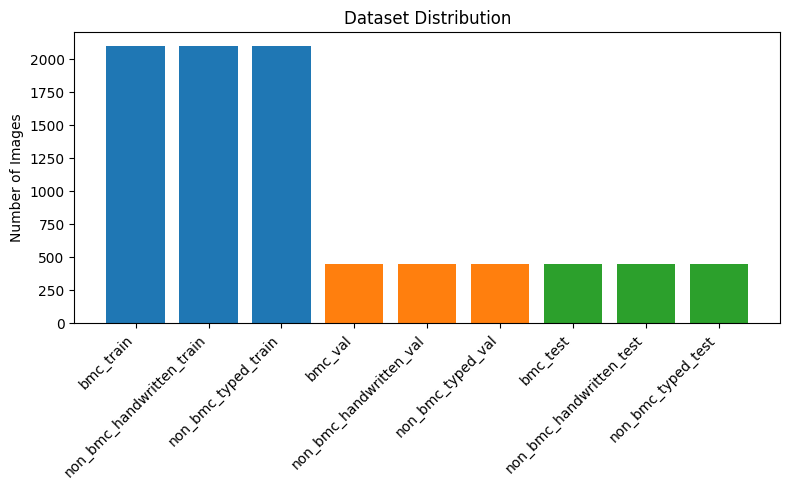

In [12]:
plt.figure(figsize=(8, 5))
for split in ["train", "val", "test"]:
    subset = distribution_df[distribution_df["split"] == split]
    plt.bar(subset["class"] + "_" + split, subset["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Dataset Distribution")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## 6. Visualize Sample Images

This section displays examples from each class to check that images were loaded correctly.

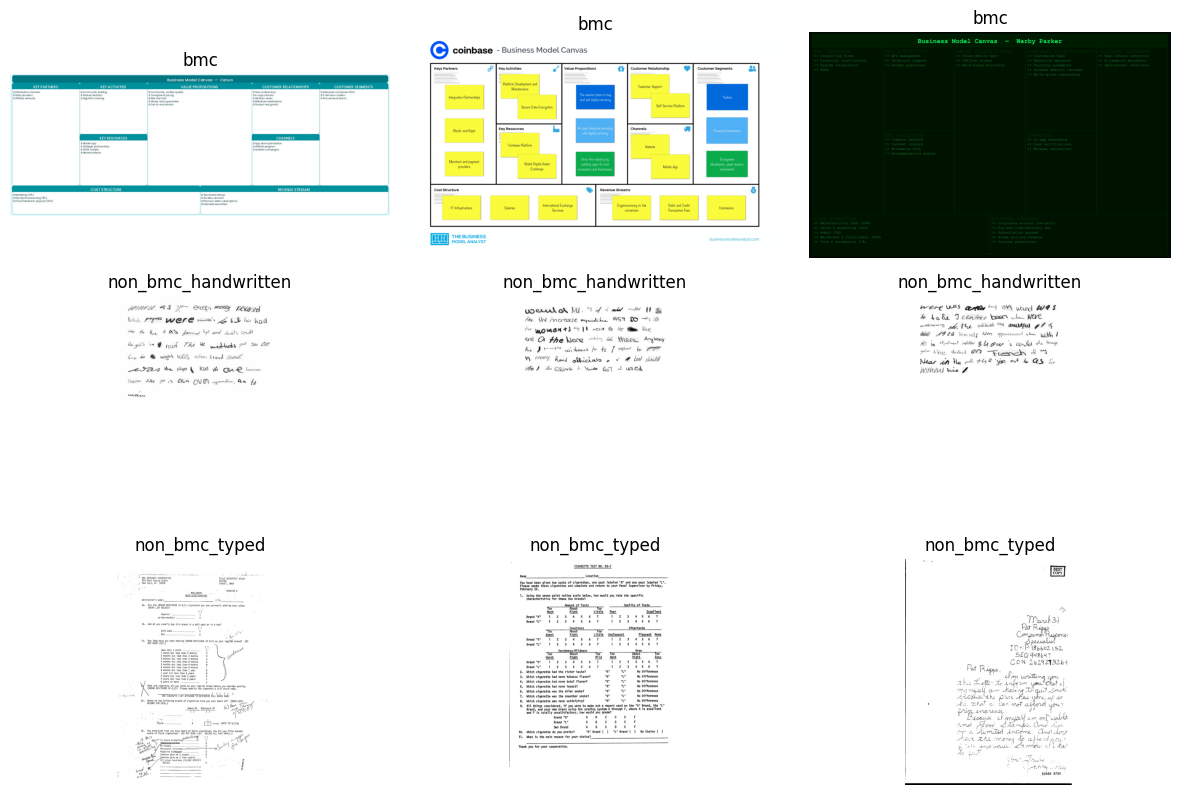

In [13]:
def show_samples(dataset_dir, split="train", samples_per_class=3):
    plt.figure(figsize=(12, 8))
    plot_idx = 1

    for cls in CLASS_NAMES:
        folder = os.path.join(dataset_dir, split, cls)
        files = [os.path.join(folder, f) for f in os.listdir(folder) if is_image_file(f)]
        files = random.sample(files, min(samples_per_class, len(files)))

        for file in files:
            img = Image.open(file).convert("RGB")
            plt.subplot(len(CLASS_NAMES), samples_per_class, plot_idx)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()

show_samples(OUTPUT_DATASET_DIR, split="train", samples_per_class=3)

## 7. Data Augmentation and DataLoaders

Training uses light augmentation to make the model robust to rotation, lighting, and scanning variations. Validation and test use deterministic preprocessing only.

In [14]:
# ============================================================
# TRANSFORMS + DATALOADERS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomRotation(25),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.75, 1.25),
        shear=8
    ),
    transforms.RandomPerspective(distortion_scale=0.45, p=0.6),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.2),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
    ], p=0.5),
    transforms.RandomGrayscale(p=0.2),

    transforms.ToTensor(),
    transforms.RandomErasing(p=0.35, scale=(0.02, 0.15), ratio=(0.3, 3.3)),

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    os.path.join(OUTPUT_DATASET_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(OUTPUT_DATASET_DIR, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(OUTPUT_DATASET_DIR, "test"),
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Class mapping:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Class mapping: {'bmc': 0, 'non_bmc_handwritten': 1, 'non_bmc_typed': 2}
Train size: 6300
Val size: 1350
Test size: 1350


## 8. Model 1 — CNN From Scratch

This CNN is trained from zero without transfer learning. It acts as a baseline model to compare against pre-trained models.

In [48]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 9. Pretrained Models

This notebook also trains:

- MobileNetV2
- EfficientNet-B0

These models use transfer learning, which is useful when the dataset is not extremely large.

In [49]:
def create_mobilenet():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, NUM_CLASSES)
    )

    return model


def create_efficientnet():
    model = timm.create_model(
        "efficientnet_b0",
        pretrained=True,
        num_classes=NUM_CLASSES,
        drop_rate=0.5
    )

    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False

    return model

## 10. Training and Evaluation Functions

Metrics used:

- Accuracy
- Macro F1-score
- Macro Precision
- Macro Recall
- Classification report
- Confusion matrix

Macro metrics are important because each class has equal importance.

In [20]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(1, len(loader))


In [ ]:
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

    return total_loss / max(1, len(loader)), acc, f1, precision, recall, all_labels, all_preds

## 11. Train All Models

The best checkpoint for each model is saved according to the validation Macro F1-score.

In [51]:
MODEL_NAMES = ["ScratchCNN", "MobileNetV2", "EfficientNetB0"]

criterion = nn.CrossEntropyLoss()
results = []
history = {}
trained_models = {}

PATIENCE = 3
WEIGHT_DECAY = 1e-4

BEST_MODEL_NAME = None
BEST_TEST_F1 = -1
BEST_MODEL_PATH = None

for model_name in MODEL_NAMES:
    print("\n" + "=" * 60)
    print(f"Training {model_name}")
    print("=" * 60)

    model = create_model_by_name(model_name).to(DEVICE)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=5e-5,
        weight_decay=1e-3
    )

    best_val_f1 = -1
    epochs_without_improvement = 0

    best_path = os.path.join(OUTPUT_MODEL_DIR, f"{model_name}_best.pth")
    history[model_name] = []

    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)

        val_loss, val_acc, val_f1, val_precision, val_recall, _, _ = evaluate_model(
            model, val_loader, criterion
        )

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1,
            "val_precision_macro": val_precision,
            "val_recall_macro": val_recall,
            "lr": optimizer.param_groups[0]["lr"]
        }
        history[model_name].append(row)

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_path)
            print(" New best model saved")
        else:
            epochs_without_improvement += 1
            print(f" No improvement: {epochs_without_improvement}/{PATIENCE}")

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    trained_models[model_name] = model

    test_loss, test_acc, test_f1, test_precision, test_recall, y_true, y_pred = evaluate_model(
        model, test_loader, criterion
    )

    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    results.append({
        "model": model_name,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "test_f1_macro": test_f1,
        "test_precision_macro": test_precision,
        "test_recall_macro": test_recall,
        "checkpoint_path": best_path
    })

    if test_f1 > BEST_TEST_F1:
        BEST_TEST_F1 = test_f1
        BEST_MODEL_NAME = model_name
        BEST_MODEL_PATH = best_path

print("\nBest model:", BEST_MODEL_NAME)
print("Best test macro F1:", BEST_TEST_F1)
print("Best checkpoint:", BEST_MODEL_PATH)


Training ScratchCNN
Epoch [1/10] Train Loss: 0.9867 | Val Loss: 0.7079 | Val Acc: 0.7215 | Val F1: 0.7143 | LR: 5.00e-05
 New best model saved
Epoch [2/10] Train Loss: 0.7973 | Val Loss: 0.4291 | Val Acc: 0.8756 | Val F1: 0.8744 | LR: 5.00e-05
 New best model saved
Epoch [3/10] Train Loss: 0.6722 | Val Loss: 0.3093 | Val Acc: 0.8622 | Val F1: 0.8613 | LR: 5.00e-05
 No improvement: 1/3
Epoch [4/10] Train Loss: 0.5782 | Val Loss: 0.2784 | Val Acc: 0.8874 | Val F1: 0.8855 | LR: 5.00e-05
 New best model saved
Epoch [5/10] Train Loss: 0.5016 | Val Loss: 0.1828 | Val Acc: 0.9252 | Val F1: 0.9233 | LR: 5.00e-05
 New best model saved
Epoch [6/10] Train Loss: 0.4455 | Val Loss: 0.1287 | Val Acc: 0.9504 | Val F1: 0.9503 | LR: 5.00e-05
 New best model saved
Epoch [7/10] Train Loss: 0.4152 | Val Loss: 0.0792 | Val Acc: 0.9770 | Val F1: 0.9770 | LR: 5.00e-05
 New best model saved
Epoch [8/10] Train Loss: 0.3801 | Val Loss: 0.1800 | Val Acc: 0.9304 | Val F1: 0.9285 | LR: 5.00e-05
 No improvement: 1

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch [1/10] Train Loss: 4.8250 | Val Loss: 1.8185 | Val Acc: 0.5622 | Val F1: 0.5328 | LR: 5.00e-05
 New best model saved
Epoch [2/10] Train Loss: 4.4980 | Val Loss: 1.4952 | Val Acc: 0.6133 | Val F1: 0.5939 | LR: 5.00e-05
 New best model saved
Epoch [3/10] Train Loss: 4.2142 | Val Loss: 1.4995 | Val Acc: 0.6089 | Val F1: 0.5883 | LR: 5.00e-05
 No improvement: 1/3
Epoch [4/10] Train Loss: 3.9449 | Val Loss: 1.3363 | Val Acc: 0.6363 | Val F1: 0.6226 | LR: 5.00e-05
 New best model saved
Epoch [5/10] Train Loss: 3.8596 | Val Loss: 1.2044 | Val Acc: 0.6711 | Val F1: 0.6552 | LR: 5.00e-05
 New best model saved
Epoch [6/10] Train Loss: 3.6158 | Val Loss: 1.2146 | Val Acc: 0.6726 | Val F1: 0.6587 | LR: 5.00e-05
 New best model saved
Epoch [7/10] Train Loss: 3.5266 | Val Loss: 1.1955 | Val Acc: 0.6778 | Val F1: 0.6597 | LR: 5.00e-05
 New best model saved
Epoch [8/10] Train Loss: 3.4230 | Val Loss: 1.0682 | Val Acc: 0.7044 | Val F1: 0.6943 | LR: 5.00e-05
 New best model saved
Epoch [9/10] Trai

## 12. Training Curves

This section shows validation performance during training for each model.

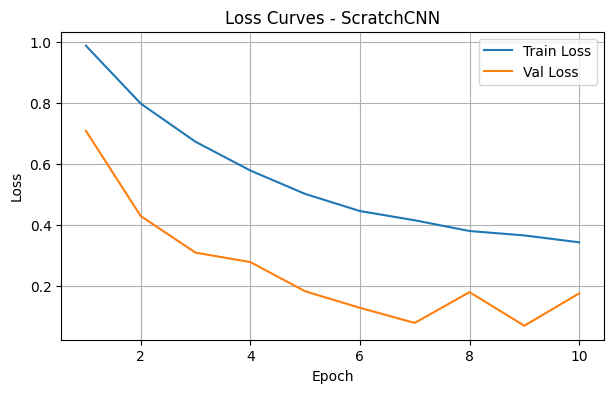

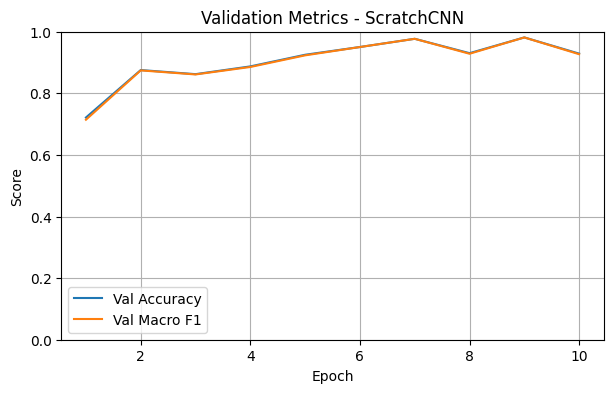

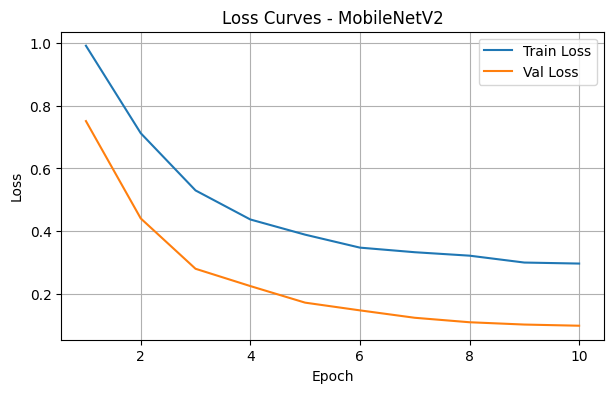

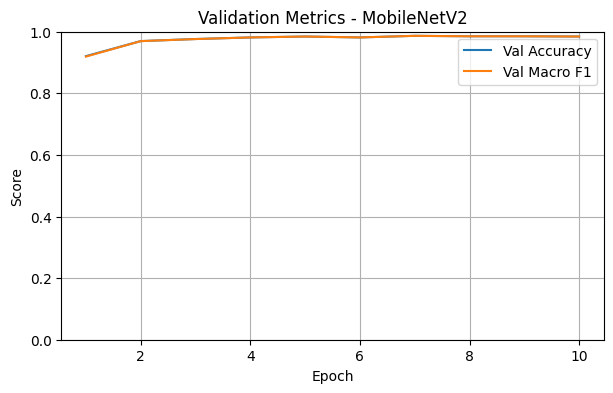

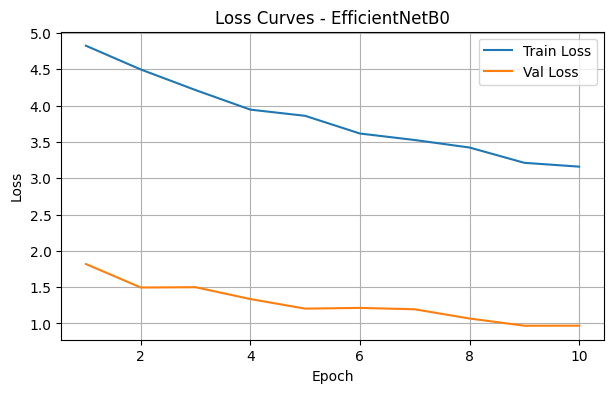

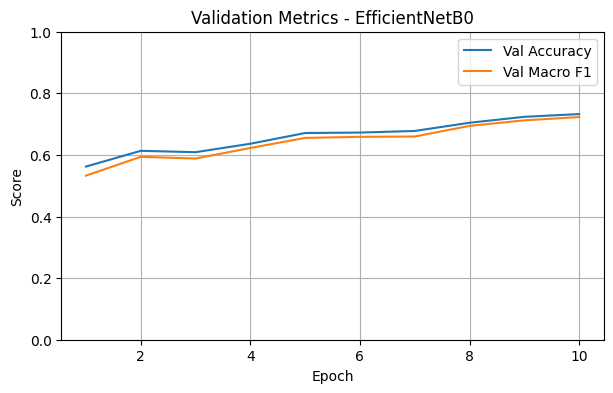

In [67]:
for model_name, rows in history.items():
    df_hist = pd.DataFrame(rows)

    plt.figure(figsize=(7, 4))
    plt.plot(df_hist["epoch"], df_hist["train_loss"], label="Train Loss")
    plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss")
    plt.title(f"Loss Curves - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(df_hist["epoch"], df_hist["val_accuracy"], label="Val Accuracy")
    plt.plot(df_hist["epoch"], df_hist["val_f1_macro"], label="Val Macro F1")
    plt.title(f"Validation Metrics - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()

## 13. Confusion Matrix for Each Model

The confusion matrix helps identify which classes are confused by each model.

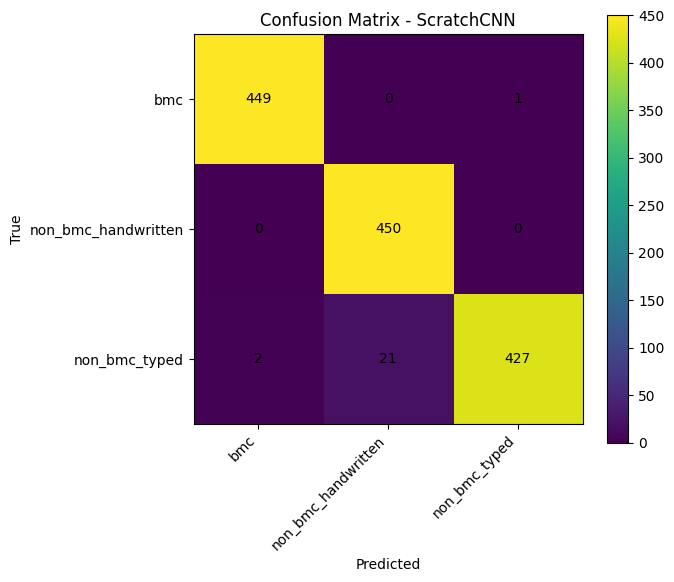

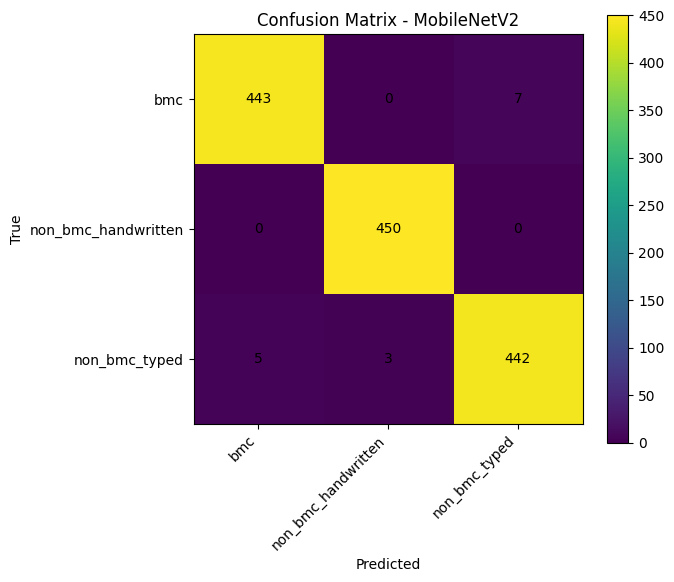

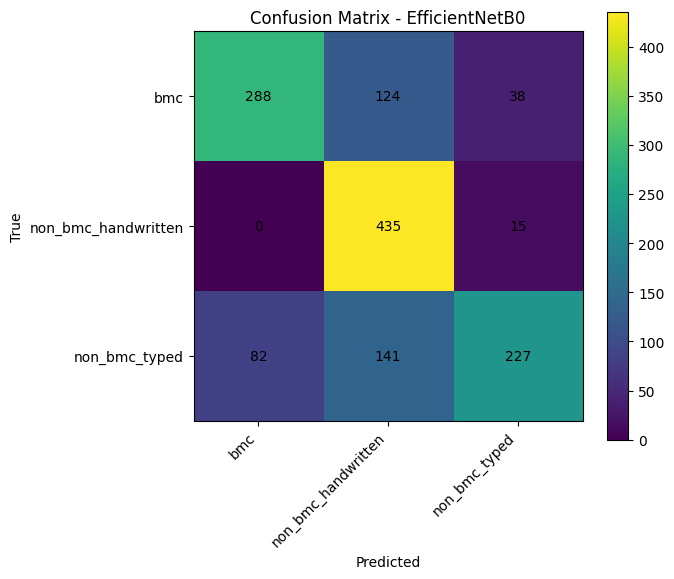

In [68]:
def plot_confusion_matrix_for_model(model_name, model):
    _, _, _, _, _, y_true, y_pred = evaluate_model(model, test_loader, criterion)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
    plt.colorbar()

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

for model_name, model in trained_models.items():
    plot_confusion_matrix_for_model(model_name, model)

## 14. XAI — Grad-CAM

Grad-CAM highlights the visual regions that influenced the model prediction.

For this project, it helps verify whether the classifier focuses on layout structure, text zones, blocks, and document organization.

In [72]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()

        # IMPORTANT for Grad-CAM
        image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
        image_tensor.requires_grad_(True)

        output = self.model(image_tensor)
        probs = torch.softmax(output, dim=1)[0].detach().cpu().numpy()

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        if self.gradients is None or self.activations is None:
            raise ValueError("Gradients not captured. Target layer may be frozen or wrong.")

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(DEVICE)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        cam = cam.detach().cpu().numpy()

        return cam, class_idx, probs

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

In [73]:
def get_target_layer(model_name, model):
    if model_name == "ScratchCNN":
        return model.features[-3]
    elif model_name == "MobileNetV2":
        return model.features[-1]
    elif model_name == "EfficientNetB0":
        return model.conv_head
    else:
        raise ValueError(f"Unknown model: {model_name}")


def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()


def show_gradcam(model_name, model, dataset, index=0):
    image_tensor, true_label = dataset[index]
    target_layer = get_target_layer(model_name, model)
    gradcam = GradCAM(model, target_layer)
    cam, pred_label, probs = gradcam.generate(image_tensor)
    gradcam.remove_hooks()

    img = denormalize(image_tensor)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original True: {CLASS_NAMES[true_label]}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(cam, alpha=0.5, cmap="jet")
    plt.title(f"Grad-CAM Pred: {CLASS_NAMES[pred_label]} | Conf: {probs[pred_label]:.2f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [74]:
for model_name, model in trained_models.items():
    for param in model.parameters():
        param.requires_grad = True

Grad-CAM XAI for ScratchCNN


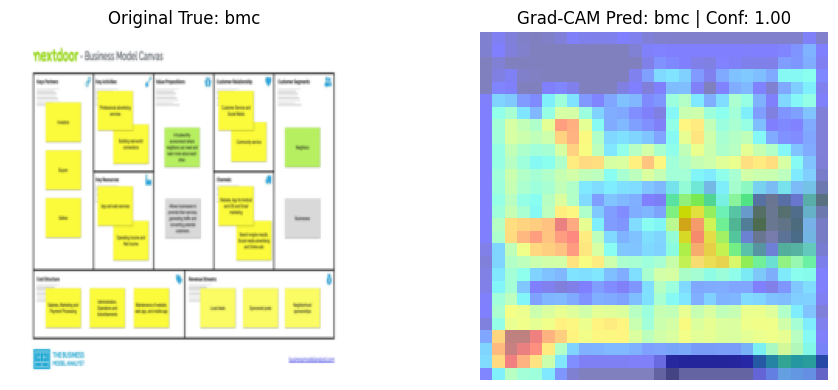

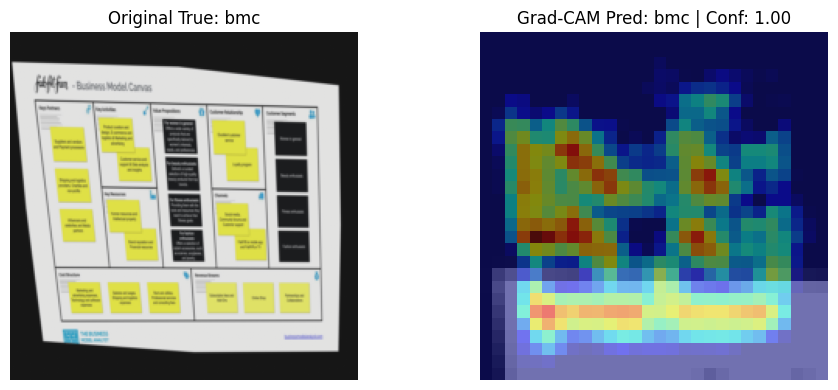

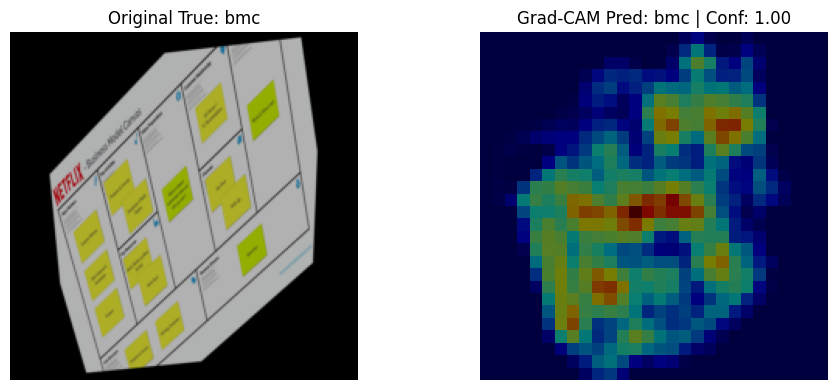

Grad-CAM XAI for MobileNetV2


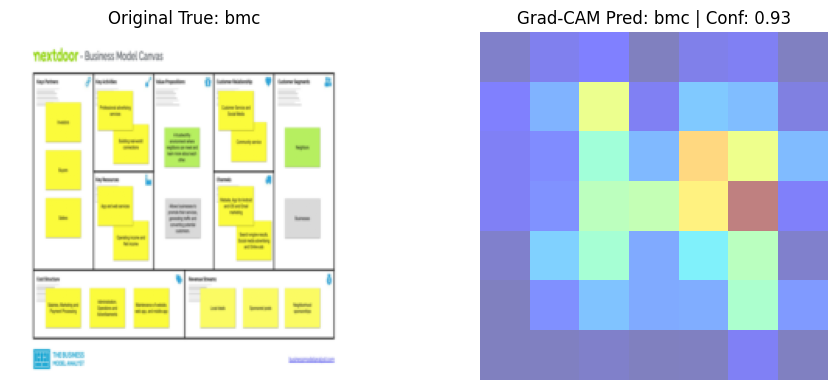

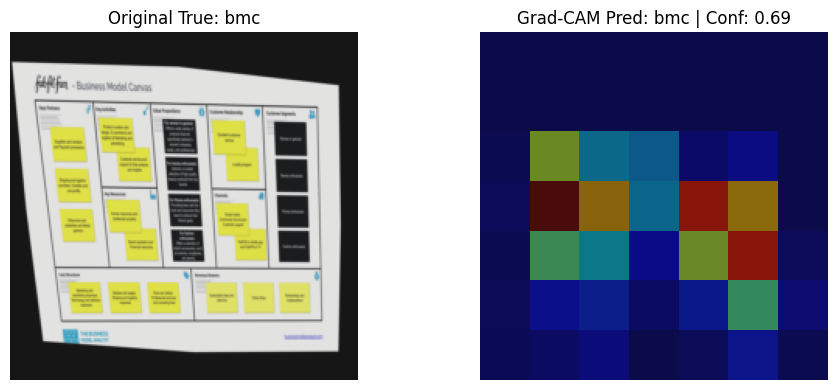

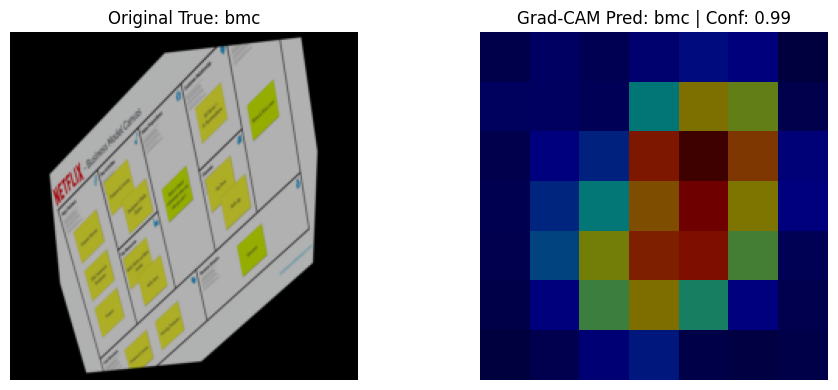

Grad-CAM XAI for EfficientNetB0


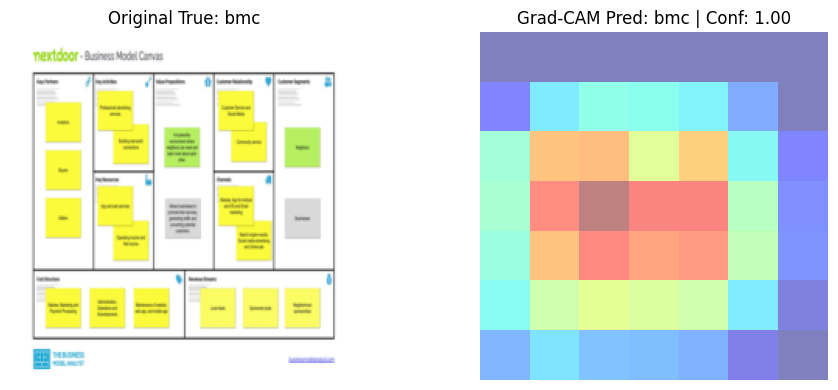

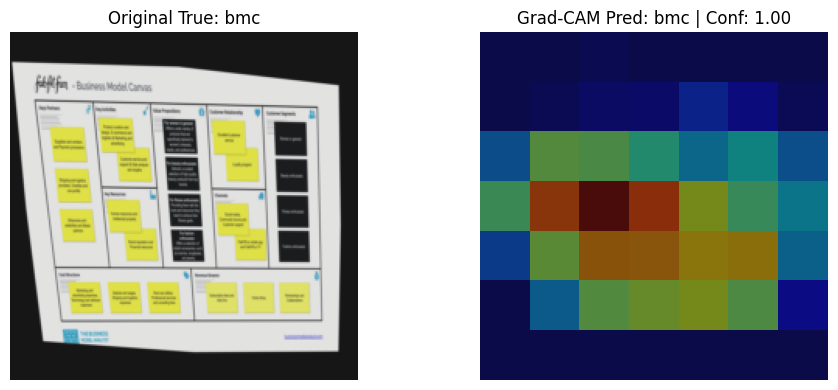

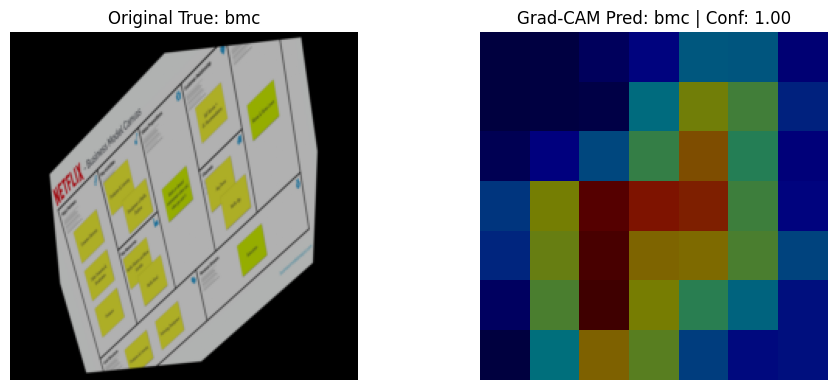

In [75]:
# Select safe sample indices from the test set
sample_indices = [0, min(10, len(test_dataset)-1), min(20, len(test_dataset)-1)]

for model_name, model in trained_models.items():
    print(" " + "=" * 60)
    print(f"Grad-CAM XAI for {model_name}")
    print("=" * 60)

    model.eval()
    for idx in sample_indices:
        show_gradcam(model_name, model, test_dataset, index=idx)

## 15. Model Comparison

The best model is selected using the test Macro F1-score because it balances performance across the three classes.

In [76]:
results_df = pd.DataFrame(results).sort_values(by="test_f1_macro", ascending=False)
results_df

,model,test_loss,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,checkpoint_path
1,MobileNetV2,0.119426,0.988889,0.988877,0.988876,0.988889,/kaggle/working/doc_type_models/MobileNetV2_be...
0,ScratchCNN,0.055571,0.982222,0.982178,0.982881,0.982222,/kaggle/working/doc_type_models/ScratchCNN_bes...
2,EfficientNetB0,1.085844,0.703704,0.693626,0.736840,0.703704,/kaggle/working/doc_type_models/EfficientNetB0...


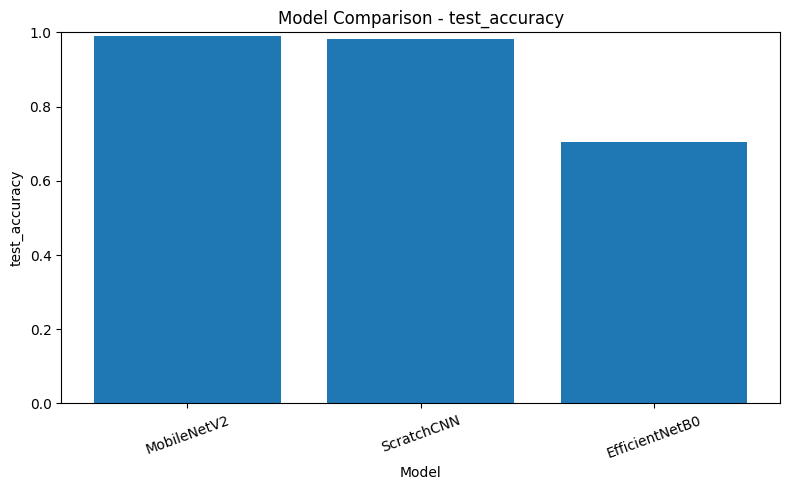

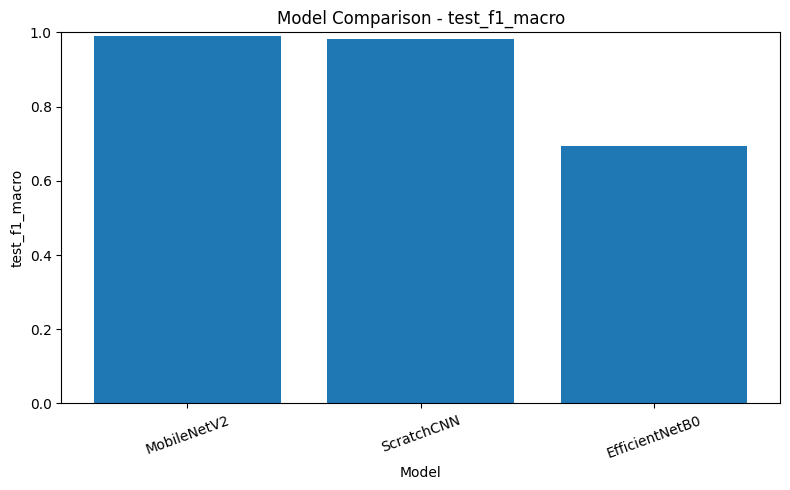

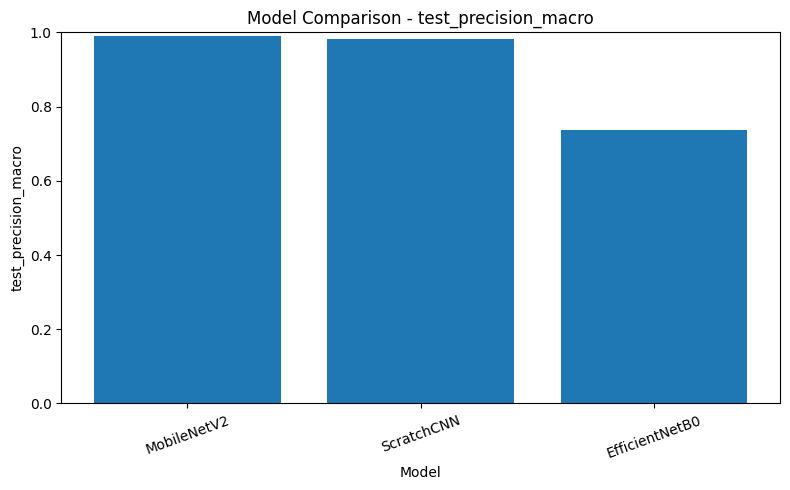

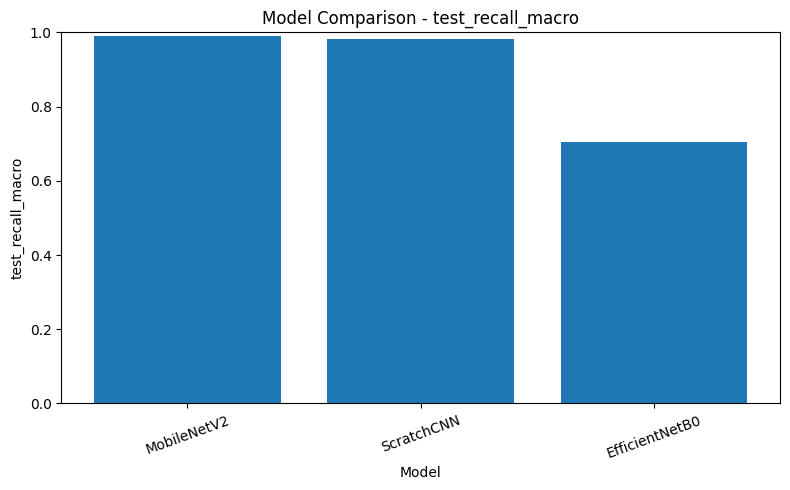

In [77]:
metrics_to_plot = ["test_accuracy", "test_f1_macro", "test_precision_macro", "test_recall_macro"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(results_df["model"], results_df[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [52]:
# ============================================================
# LOAD BEST MODEL FOR INFERENCE
# ============================================================

def load_best_model(model_name, checkpoint_path):
    if model_name == "ScratchCNN":
        model = ScratchCNN(NUM_CLASSES)
    elif model_name == "MobileNetV2":
        model = create_mobilenet()
    elif model_name == "EfficientNetB0":
        model = create_efficientnet()
    else:
        raise ValueError("Unknown model")

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    
    return model

BEST_MODEL = load_best_model(BEST_MODEL_NAME, BEST_MODEL_PATH)

print("Loaded:", BEST_MODEL_NAME)

Loaded: MobileNetV2


In [66]:
# ============================================================
# TEST ONE IMAGE WITH ALL TRAINED MODELS
# ============================================================

from PIL import Image
import torch
import os

MODEL_PATHS = {
    "ScratchCNN": "/kaggle/working/doc_type_models/ScratchCNN_best.pth",
    "MobileNetV2": "/kaggle/working/doc_type_models/MobileNetV2_best.pth",
    "EfficientNetB0": "/kaggle/working/doc_type_models/EfficientNetB0_best.pth"
}

img_path = "/kaggle/input/datasets/fatmaadorgham/test-integ/page_0001_1.png"

img = Image.open(img_path).convert("RGB")
img_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)

for model_name, checkpoint_path in MODEL_PATHS.items():
    print("\n" + "=" * 50)
    print("Model:", model_name)

    if not os.path.exists(checkpoint_path):
        print("Checkpoint not found:", checkpoint_path)
        continue

    model = create_model_by_name(model_name)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred = torch.argmax(probs).item()

    print("Prediction:", CLASS_NAMES[pred])
    print("Confidence:", round(float(probs[pred]), 4))

    for cls, p in zip(CLASS_NAMES, probs.cpu().numpy()):
        print(cls, ":", round(float(p), 4))


Model: ScratchCNN
Prediction: bmc
Confidence: 1.0
bmc : 1.0
non_bmc_handwritten : 0.0
non_bmc_typed : 0.0

Model: MobileNetV2
Prediction: bmc
Confidence: 0.9415
bmc : 0.9415
non_bmc_handwritten : 0.0226
non_bmc_typed : 0.0359

Model: EfficientNetB0
Prediction: bmc
Confidence: 0.992
bmc : 0.992
non_bmc_handwritten : 0.0006
non_bmc_typed : 0.0074


## 16. Save the Best Model for Deployment

The best model is saved with:

- model name
- model weights
- class names
- image size

This file can be used later in your full BMC pipeline.

In [80]:
best_model = create_model_by_name(BEST_MODEL_NAME).to(DEVICE)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.eval()

BEST_SAVE_PATH = os.path.join(OUTPUT_MODEL_DIR, "best_doc_type_classifier.pth")

checkpoint = {
    "model_name": BEST_MODEL_NAME,
    "model_state_dict": best_model.state_dict(),
    "class_names": CLASS_NAMES,
    "class_to_idx": train_dataset.class_to_idx,
    "img_size": IMG_SIZE,
    "test_f1_macro": BEST_TEST_F1
}

torch.save(checkpoint, BEST_SAVE_PATH)

with open(os.path.join(OUTPUT_MODEL_DIR, "model_comparison.json"), "w") as f:
    json.dump(results, f, indent=4)

results_df.to_csv(os.path.join(OUTPUT_MODEL_DIR, "model_comparison.csv"), index=False)

print("Best model:", BEST_MODEL_NAME)
print("Best test Macro F1:", BEST_TEST_F1)
print("Saved checkpoint:", BEST_SAVE_PATH)

Best model: MobileNetV2
Best test Macro F1: 0.9888765020421179
Saved checkpoint: /kaggle/working/doc_type_models/best_doc_type_classifier.pth


In [81]:
# ============================================================
# SAVE EFFICIENTNET CHECKPOINT ALSO
# ============================================================

EFFICIENTNET_PATH = os.path.join(OUTPUT_MODEL_DIR, "EfficientNetB0_best.pth")
EFFICIENTNET_SAVE_PATH = os.path.join(OUTPUT_MODEL_DIR, "efficientnet_doc_type_classifier.pth")

efficientnet_model = create_model_by_name("EfficientNetB0").to(DEVICE)
efficientnet_model.load_state_dict(torch.load(EFFICIENTNET_PATH, map_location=DEVICE))
efficientnet_model.eval()

efficientnet_checkpoint = {
    "model_name": "EfficientNetB0",
    "model_state_dict": efficientnet_model.state_dict(),
    "class_names": CLASS_NAMES,
    "class_to_idx": train_dataset.class_to_idx,
    "img_size": IMG_SIZE
}

torch.save(efficientnet_checkpoint, EFFICIENTNET_SAVE_PATH)

print("EfficientNet saved to:", EFFICIENTNET_SAVE_PATH)

EfficientNet saved to: /kaggle/working/doc_type_models/efficientnet_doc_type_classifier.pth


## 17. Deployment Inference Function

This function loads the saved model and predicts the document type of a new image.

In [82]:
def load_best_model(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model_name = checkpoint["model_name"]
    class_names = checkpoint["class_names"]

    model = create_model_by_name(model_name)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    return model, class_names


def predict_doc_type(image_path, model, class_names):
    img = Image.open(image_path).convert("RGB")
    img_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        confidence = probs[pred_idx].item()

    return {
        "predicted_class": class_names[pred_idx],
        "confidence": confidence,
        "all_probabilities": {class_names[i]: probs[i].item() for i in range(len(class_names))}
    }

Sample image: /kaggle/working/doc_type_dataset/test/bmc/bmc_00000.jpg
{'predicted_class': 'bmc', 'confidence': 0.9295516610145569, 'all_probabilities': {'bmc': 0.9295516610145569, 'non_bmc_handwritten': 0.03758878633379936, 'non_bmc_typed': 0.03285950422286987}}


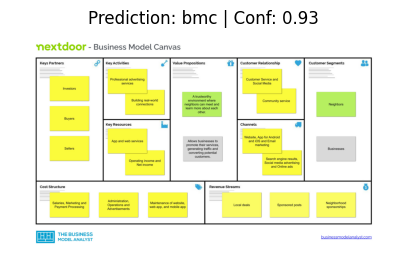

In [83]:
deployed_model, deployed_class_names = load_best_model(BEST_SAVE_PATH)

sample_image_path = test_dataset.samples[0][0]
prediction = predict_doc_type(sample_image_path, deployed_model, deployed_class_names)

print("Sample image:", sample_image_path)
print(prediction)

img = Image.open(sample_image_path).convert("RGB")
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Prediction: {prediction['predicted_class']} | Conf: {prediction['confidence']:.2f}")
plt.axis("off")
plt.show()

In [84]:
import shutil

shutil.make_archive(
    "/kaggle/working/doc_type_models",
    'zip',
    "/kaggle/working/doc_type_models"
)

print("Zipped!")

Zipped!


In [85]:
import shutil

shutil.copy(
    "/kaggle/working/doc_type_models/efficientnet_doc_type_classifier.pth",
    "/kaggle/working/efficientnet.pth"
)

'/kaggle/working/efficientnet.pth'

In [86]:
shutil.make_archive("/kaggle/working/models", 'zip', "/kaggle/working/doc_type_models")

'/kaggle/working/models.zip'

# Fine Tunning MobileNet

In [ ]:
def create_mobilenet_full_finetune():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    # Unfreeze ALL layers
    for param in model.parameters():
        param.requires_grad = True

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, NUM_CLASSES)
    )

    return model

In [15]:
import torch
import torch.nn as nn
from torchvision import models

def create_mobilenet_full_finetune():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = True

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, NUM_CLASSES)
    )

    return model

In [16]:
model = create_mobilenet_full_finetune().to(DEVICE)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 125MB/s]


In [17]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,         
    weight_decay=1e-4
)

In [18]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.3
)

In [23]:
criterion = nn.CrossEntropyLoss()

In [24]:
from tqdm import tqdm
from sklearn.metrics import f1_score
import copy

EPOCHS = 5
PATIENCE = 3

best_val_f1 = 0.0
patience_counter = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    avg_train_loss = train_loss / len(train_loader)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # ================= SAVE BEST + EARLY STOPPING =================
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(model.state_dict(), "mobilenet_full_finetune_best.pth")
        print(" Saved best model")
    else:
        patience_counter += 1
        print(f" No improvement. Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break

    scheduler.step()

print(f"\nBest Validation Macro F1: {best_val_f1:.4f}")


Epoch 1/10


100%|██████████| 197/197 [02:26<00:00,  1.34it/s]


Train Loss: 1.0565 | Train Acc: 0.4802
Val Loss:   0.9544 | Val Acc:   0.8993 | Val F1: 0.8995
✅ Saved best model

Epoch 2/10


100%|██████████| 197/197 [02:29<00:00,  1.32it/s]


Train Loss: 0.8914 | Train Acc: 0.7397
Val Loss:   0.5851 | Val Acc:   0.9674 | Val F1: 0.9673
✅ Saved best model

Epoch 3/10


...

Train Loss: 0.2309 | Train Acc: 0.9587
Val Loss:   0.1224 | Val Acc:   0.9978 | Val F1: 0.9978
✅ Saved best model

Epoch 9/10


100%|██████████| 197/197 [02:27<00:00,  1.34it/s]


Train Loss: 0.2223 | Train Acc: 0.9556
Val Loss:   0.1204 | Val Acc:   0.9978 | Val F1: 0.9978
⚠️ No improvement. Patience: 1/3

Epoch 10/10


100%|██████████| 197/197 [02:21<00:00,  1.39it/s]


Train Loss: 0.2108 | Train Acc: 0.9624
Val Loss:   0.1107 | Val Acc:   0.9963 | Val F1: 0.9963
⚠️ No improvement. Patience: 2/3

Best Validation Macro F1: 0.9978


✅ Model loaded successfully


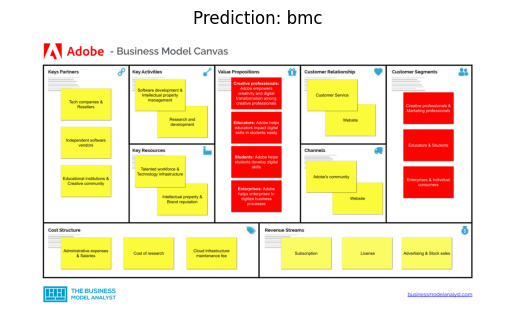

Predicted class: bmc
Probabilities: [[0.9306169  0.0260812  0.04330184]]


In [28]:
# ============================================================
# FULL INFERENCE PIPELINE 
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# ================= CONFIG =================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224  # make sure it's same as training

# ================= MODEL =================
def create_mobilenet_full_finetune():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    # Unfreeze all layers
    for param in model.parameters():
        param.requires_grad = True

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, NUM_CLASSES)
    )

    return model

# ================= LOAD MODEL =================
model = create_mobilenet_full_finetune().to(DEVICE)

model.load_state_dict(torch.load("mobilenet_full_finetune_best.pth", map_location=DEVICE))
model.eval()

print("✅ Model loaded successfully")

# ================= TRANSFORM =================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ================= CLASS MAPPING =================
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

# ================= PREDICTION FUNCTION =================
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return image, pred, probs.cpu().numpy()

# ================= TEST =================
image_path = "/kaggle/input/datasets/fatmaadorgham/test-integ/page_0001_1.png"  # 🔥 CHANGE THIS

image, pred, probs = predict_image(image_path)

# ================= DISPLAY =================
plt.imshow(image)
plt.title(f"Prediction: {idx_to_class[pred]}")
plt.axis("off")
plt.show()

print("Predicted class:", idx_to_class[pred])
print("Probabilities:", probs)